In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os

In [3]:
DATA_DIR = "dataset"

TRAIN_DIR = os.path.join(DATA_DIR, "Train")
TEST_DIR = os.path.join(DATA_DIR, "Test")

TRAIN_CSV = os.path.join(DATA_DIR, "Train.csv")
TEST_CSV = os.path.join(DATA_DIR, "Test.csv")
SIGNNAMES_CSV = os.path.join(DATA_DIR, "signnames.csv")

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 138516

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="training",
    seed=SEED,
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="validation",
    seed=SEED,
    shuffle=False
)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


In [5]:
len(os.listdir(TEST_DIR))

12632

In [7]:
from tensorflow.keras import layers

model = tf.keras.models.Sequential([

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same" , input_shape= (32 , 32 , 3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),


    # Block 2
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),


    # Feature aggregation
    layers.GlobalAveragePooling2D(),


    # Classifier
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    # Output
    layers.Dense(43, activation="softmax")
])

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,89

 Total params: 122,443 (478.29 KB)

 Trainable params: 121,547 (474.79 KB)

 Non-trainable params: 896 (3.50 KB)

In [10]:
print(validation_generator.image_shape)

(32, 32, 3)


In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    mode="max",
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)

Epoch 1/30
271/981 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.1086 - loss: 3.3962

I0000 00:00:1786351112.220068     727 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5326__.67


979/981 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2111 - loss: 2.8132

I0000 00:00:1786351129.996687     727 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786351130.657443    1458 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 12 bytes spill stores, 12 bytes spill loads



981/981 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - accuracy: 0.2112 - loss: 2.8118 - val_accuracy: 0.2079 - val_loss: 2.5721
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.4538 - loss: 1.6780 - val_accuracy: 0.4649 - val_loss: 1.6807
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6183 - loss: 1.1448 - val_accuracy: 0.5902 - val_loss: 1.4839
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7628 - loss: 0.7229 - val_accuracy: 0.7113 - val_loss: 0.9879
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8485 - loss: 0.4641 - val_accuracy: 0.8148 - val_loss: 0.5803
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8947 - loss: 0.3267 - val_accuracy: 0.8861 - val_loss: 0.3973
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9231 - loss: 0.2455 - val_accuracy: 0.8370 - val_loss: 0.5316
Epoch 8/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9370 - loss: 0.1986 - val_accuracy:

In [13]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

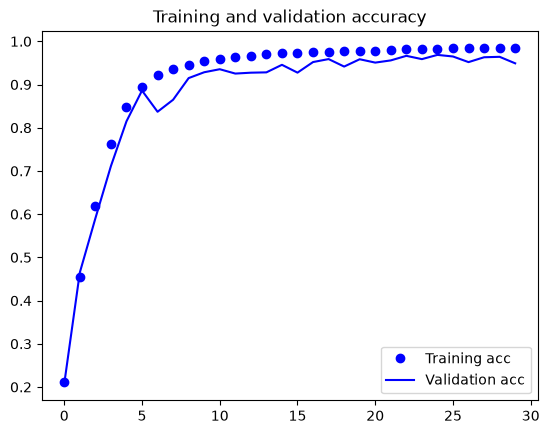

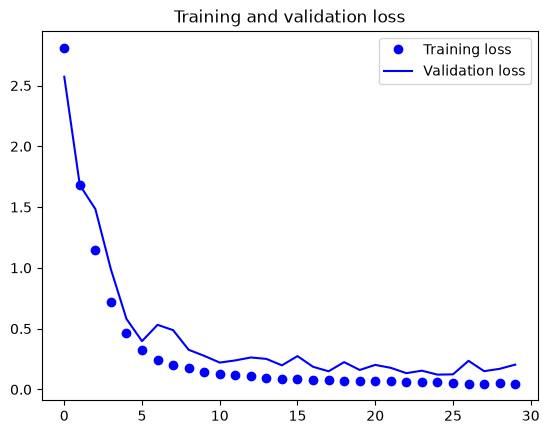

In [14]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [16]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator


test_df = pd.read_csv(TEST_CSV)

print("Columns:")
print(test_df.columns.tolist())

print("\nFirst rows:")
print(test_df.head())



test_df["Filename"] = test_df["Path"].apply(
    lambda x: os.path.basename(x)
)

print("\nFilenames:")
print(test_df[["Path", "Filename"]].head())



test_df["FullPath"] = test_df["Filename"].apply(
    lambda x: os.path.join(TEST_DIR, x)
)

print("\nFull paths:")
print(test_df[["Filename", "FullPath"]].head())




print("\nFirst image exists:")
print(os.path.exists(test_df["FullPath"].iloc[0]))

print("\nNumber of existing images:")

existing_images = test_df["FullPath"].apply(
    os.path.exists
).sum()

print(existing_images)
print("Total images:", len(test_df))



test_df["ClassId"] = test_df["ClassId"].astype(str)



test_datagen = ImageDataGenerator(
    rescale=1./255
)


test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="FullPath",
    y_col="ClassId",
    target_size=(32, 32),
    batch_size=32,
    class_mode="sparse",
    shuffle=False
)



test_loss, test_accuracy = model.evaluate(
    test_generator
)

print("\n======================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("======================")

Columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

First rows:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     53      54       6       5      48      49       16   
1     42      45       5       5      36      40        1   
2     48      52       6       6      43      47       38   
3     27      29       5       5      22      24       33   
4     60      57       5       5      55      52       11   

                   Path  
0  /code/Test/00000.png  
1  /code/Test/00001.png  
2  /code/Test/00002.png  
3  /code/Test/00003.png  
4  /code/Test/00004.png  

Filenames:
                   Path   Filename
0  /code/Test/00000.png  00000.png
1  /code/Test/00001.png  00001.png
2  /code/Test/00002.png  00002.png
3  /code/Test/00003.png  00003.png
4  /code/Test/00004.png  00004.png

Full paths:
    Filename                FullPath
0  00000.png  dataset/Test/00000.png
1  00001.png  dataset/Test/00001.png
2  00002.png  dataset/Test/000

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


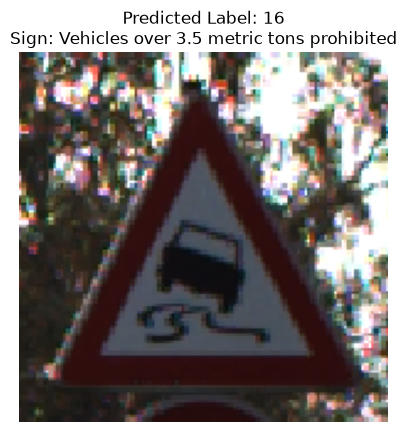

Predicted Label: 16
Sign Name: Vehicles over 3.5 metric tons prohibited


In [20]:
import keras.utils as image

sign = pd.read_csv(SIGNNAMES_CSV)
sign.style.hide(axis="index")

fnames = [os.path.join(TEST_DIR, fname) for fname in os.listdir(TEST_DIR)]

img_path = fnames[0]
img = image.load_img(img_path, target_size=IMG_SIZE)
img2 = image.load_img(img_path, target_size=(150 , 150))
x = image.img_to_array(img)

x = np.expand_dims(x, axis=0)

x = x / 255.0

preds = model.predict(x)

predicted_label = np.argmax(preds[0])


sign_name = sign.loc[
sign["ClassId"] == predicted_label,
    "SignName"
].values[0]

plt.imshow(img2)
plt.axis("off")
plt.title(f"Predicted Label: {predicted_label}\nSign: {sign_name}")
plt.show()

print("Predicted Label:", predicted_label)
print("Sign Name:", sign_name)

